# Imports and Installs

In [8]:
!pip install geopandas

In [9]:
import pandas as pd
import kagglehub
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import gzip
import numpy as np
from google.colab import files
from google.colab import drive

# Kaggle NOAA Coral Dataset EDA

We analyze the dataset from NOAA on deep-sea corals by investigating distributions of coral species, location, depth, date of observation...

In [10]:
#downloading the data from kaggle
path = kagglehub.dataset_download("noaa/deep-sea-corals")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deep-sea-corals' dataset.
Path to dataset files: /kaggle/input/deep-sea-corals


In [11]:

os.listdir(path)

['.nfs000000005a8b355600000006', 'deep_sea_corals.csv']

In [12]:
df = pd.read_csv(os.path.join(path, 'deep_sea_corals.csv'))
df.head()

/tmp/ipykernel_8743/273813967.py:1: DtypeWarning: Columns (5,7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'deep_sea_corals.csv'))


,CatalogNumber,DataProvider,ScientificName,VernacularNameCategory,TaxonRank,Station,ObservationDate,latitude,longitude,DepthInMeters,DepthMethod,Locality,LocationAccuracy,SurveyID,Repository,IdentificationQualifier,EventID,SamplingEquipment,RecordType,SampleID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,degrees_north,degrees_east,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,625366.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-02,18.30817,-158.45392,959.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:45:26:28
2,625373.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30864,-158.45393,953.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:24:35:53
3,625386.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30877,-158.45384,955.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:15:22:09
4,625382.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30875,-158.45384,955.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:13:29:50


## Visualizing where the observations are from

In [16]:
!wget https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip


--2026-03-23 18:22:55--  https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
Resolving naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)... 52.92.163.1, 16.12.99.217, 52.92.236.97, ...
Connecting to naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)|52.92.163.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 214976 (210K) [application/zip]
Saving to: ‘ne_110m_admin_0_countries.zip’

ne_110m_admin_0_cou 100%[===================>] 209.94K  1.14MB/s    in 0.2s    

2026-03-23 18:22:56 (1.14 MB/s) - ‘ne_110m_admin_0_countries.zip’ saved [214976/214976]



In [17]:
!unzip ne_110m_admin_0_countries.zip


Archive:  ne_110m_admin_0_countries.zip
  inflating: ne_110m_admin_0_countries.README.html  
 extracting: ne_110m_admin_0_countries.VERSION.txt  
 extracting: ne_110m_admin_0_countries.cpg  
  inflating: ne_110m_admin_0_countries.dbf  
  inflating: ne_110m_admin_0_countries.prj  
  inflating: ne_110m_admin_0_countries.shp  
  inflating: ne_110m_admin_0_countries.shx  


In [18]:
df.head()

,CatalogNumber,DataProvider,ScientificName,VernacularNameCategory,TaxonRank,Station,ObservationDate,latitude,longitude,DepthInMeters,DepthMethod,Locality,LocationAccuracy,SurveyID,Repository,IdentificationQualifier,EventID,SamplingEquipment,RecordType,SampleID
0,625373.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30864,-158.45393,953.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:24:35:53
1,625386.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30877,-158.45384,955.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:15:22:09
2,625382.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30875,-158.45384,955.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_05:13:29:50
3,625384.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-01,18.30902,-158.45425,968.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_04:24:44:48
4,625375.0,"NOAA, Deep Sea Coral Research & Technology Pro...",Madrepora oculata,stony coral (branching),species,D2-EX1504L3-05,2015-09-02,18.30746,-158.45412,976.0,reported,"Hawaiian Archipelago, Swordfish Seamount",50m,Hohonu Moana: Exploring Deep Waters off Hawai'i,University of Hawaii,ID by expert from video,D2-EX1504L3-05,ROV,video observation,EX1504L3_05_20150901T181522Z.mp4_06:16:24:00


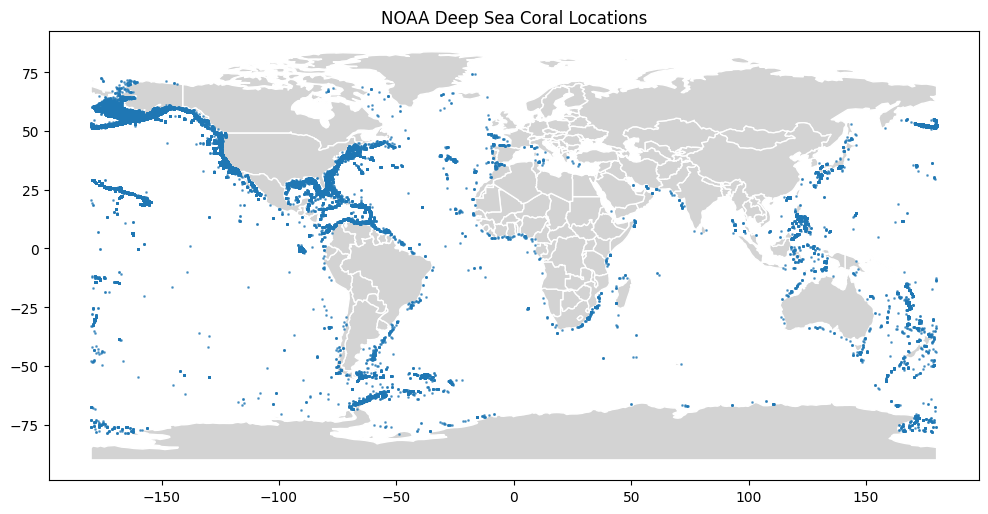

In [19]:


world = gpd.read_file("ne_110m_admin_0_countries.shp")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

ax = world.plot(figsize=(12, 8), color="lightgray", edgecolor="white")
gdf.plot(ax=ax, markersize=1, alpha=0.6)

plt.title("NOAA Deep Sea Coral Locations")
plt.show()


## When are observations from?



/tmp/ipykernel_8743/3462966237.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  counts = df.dropna(subset=["ObservationDate"]).groupby(pd.Grouper(key="ObservationDate", freq="M")).size()


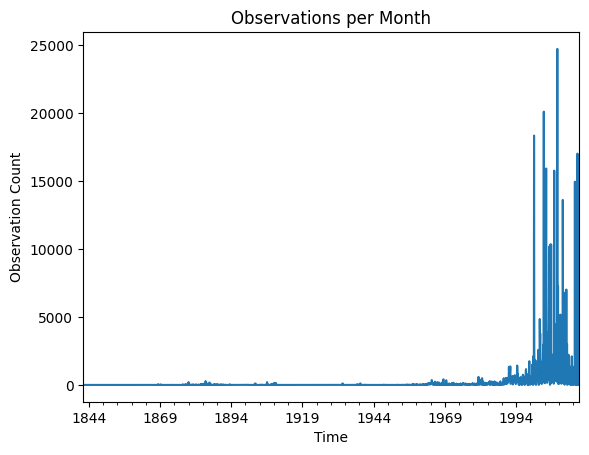

In [20]:


df["ObservationDate"] = pd.to_datetime(df["ObservationDate"], errors="coerce")
counts = df.dropna(subset=["ObservationDate"]).groupby(pd.Grouper(key="ObservationDate", freq="M")).size()

counts.plot()
plt.xlabel("Time")
plt.ylabel("Observation Count")
plt.title("Observations per Month")
plt.show()


## Number of Observations per Repository

In [21]:
df["Repository"].nunique()

62

In [22]:
df["Repository"].unique()

array(['University of Hawaii',
       'University of Hawaii (Video); National Museum of Natural History, Smithsonian Institution, Washington D.C. (sample)',
       'National Museum of Natural History, Smithsonian Institution, Washington D.C.',
       'Harbor Branch Oceanographic Institute',
       'Hawaii Undersea Research Laboratory, University of Hawaii',
       'Texas A&M Biodiversity Research and Teaching Collections (BRTC)',
       'NOAA Deep Sea Coral Research and Technology Program',
       'Texas Cooperative Wildlife Collection, Texas A&M University',
       'Temple University', nan, 'Texas A&M University',
       'Museum of Comparative Zoology, Harvard University, Zoological Collections',
       'NOAA', 'NOAA, Southwest Fisheries Science Center',
       'NOAA, Flower Garden Banks National Marine Sanctuary',
       'Bishop Museum, Invertebrate Zoology Collection',
       'Peabody Museum, Yale University',
       'NOAA, Center for Coastal Environmental Health and Biomolecular Re

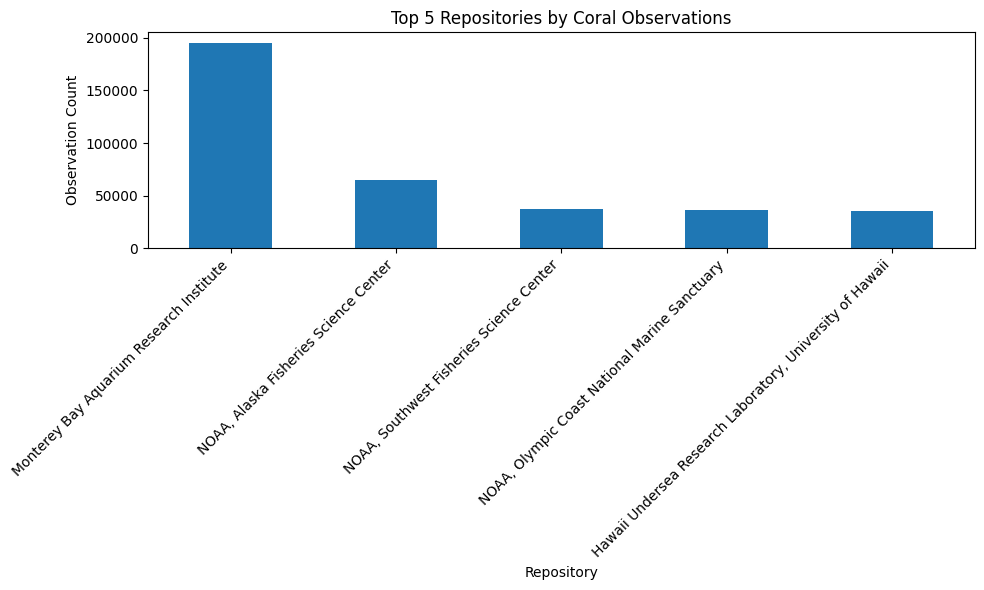

In [23]:


counts = (df.dropna(subset=["Repository"])
            .groupby(pd.Grouper(key="Repository")).size()
            .sort_values(ascending = False)
            .head(5))


counts.plot(kind="bar", figsize=(10,6))

plt.xlabel("Repository")
plt.ylabel("Observation Count")
plt.title("Top 5 Repositories by Coral Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [24]:
df.describe()

,CatalogNumber,ObservationDate,DepthInMeters
count,513371.000000,497576,513371.000000
mean,426606.876551,2003-07-05 22:50:57.600849024,798.589457
min,1.000000,1842-01-01 00:00:00,-999.000000
25%,222081.500000,2002-07-08 00:00:00,218.000000
50%,469248.000000,2006-01-17 00:00:00,539.000000
75%,604060.500000,2009-09-01 00:00:00,1137.000000
max,740097.000000,2016-03-27 00:00:00,6369.000000
std,206162.556642,NaN,805.992255


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513371 entries, 0 to 513370
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   CatalogNumber            513371 non-null  float64       
 1   DataProvider             513371 non-null  object        
 2   ScientificName           513371 non-null  object        
 3   VernacularNameCategory   513196 non-null  object        
 4   TaxonRank                513363 non-null  object        
 5   Station                  253589 non-null  object        
 6   ObservationDate          497576 non-null  datetime64[ns]
 7   latitude                 513371 non-null  object        
 8   longitude                513371 non-null  object        
 9   DepthInMeters            513371 non-null  float64       
 10  DepthMethod              496844 non-null  object        
 11  Locality                 389644 non-null  object        
 12  LocationAccuracy

For now, we will only be interested in the following fields


*   Scientific Name
*   Latitude
*   Longitude
*   Depth
*   Date

The only column that has missing values from those listed above is Date. However, we know we need to take a subset of the data anyways (we have too much already), so we hold off on filtering for non-null.

It also looks like some of the depth values are dummy variables (-999), so we have to filter for depths greater than 0.







## Examining Potential Subsets of Data

We want to pull data from a single location for analysis, so we choose one of the top 5 repositories with the most observation counts. We examine the spread of area covered, species, depth, and dates for each of these repositories.

### Area covered

In [26]:
df["latitude"]  = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

In [27]:
top5 = df["Repository"].dropna().value_counts().head(5).index


In [28]:
repo_area = (
    df[df["Repository"].isin(top5)]
      .dropna(subset=["latitude", "longitude"])
      .groupby("Repository")
      .agg(
          min_lat=("latitude", "min"),
          max_lat=("latitude", "max"),
          min_lon=("longitude", "min"),
          max_lon=("longitude", "max"),
          count=("latitude", "size")
      )
)

#computing spans
repo_area["lat_span"] = repo_area["max_lat"] - repo_area["min_lat"]
repo_area["lon_span"] = repo_area["max_lon"] - repo_area["min_lon"]

#area in degrees
repo_area["area_deg2"] = repo_area["lat_span"] * repo_area["lon_span"]

repo_area.sort_values("area_deg2", ascending=False)


,min_lat,max_lat,min_lon,max_lon,count,lat_span,lon_span,area_deg2
Repository,,,,,,,,
"NOAA, Alaska Fisheries Science Center",34.13000,71.59183,-179.99358,179.99260,64851,37.46183,359.98618,13485.741078
Monterey Bay Aquarium Research Institute,19.11710,49.35187,-160.38654,-108.11498,195477,30.23477,52.27156,1580.418594
"Hawaii Undersea Research Laboratory, University of Hawaii",-14.55684,28.96923,-179.57098,-154.80000,35101,43.52607,24.77098,1078.183409
"NOAA, Southwest Fisheries Science Center",31.41184,48.17706,-125.36218,-116.62170,37587,16.76522,8.74048,146.536070
"NOAA, Olympic Coast National Marine Sanctuary",47.99143,48.30500,-125.37854,-124.93027,36279,0.31357,0.44827,0.140564


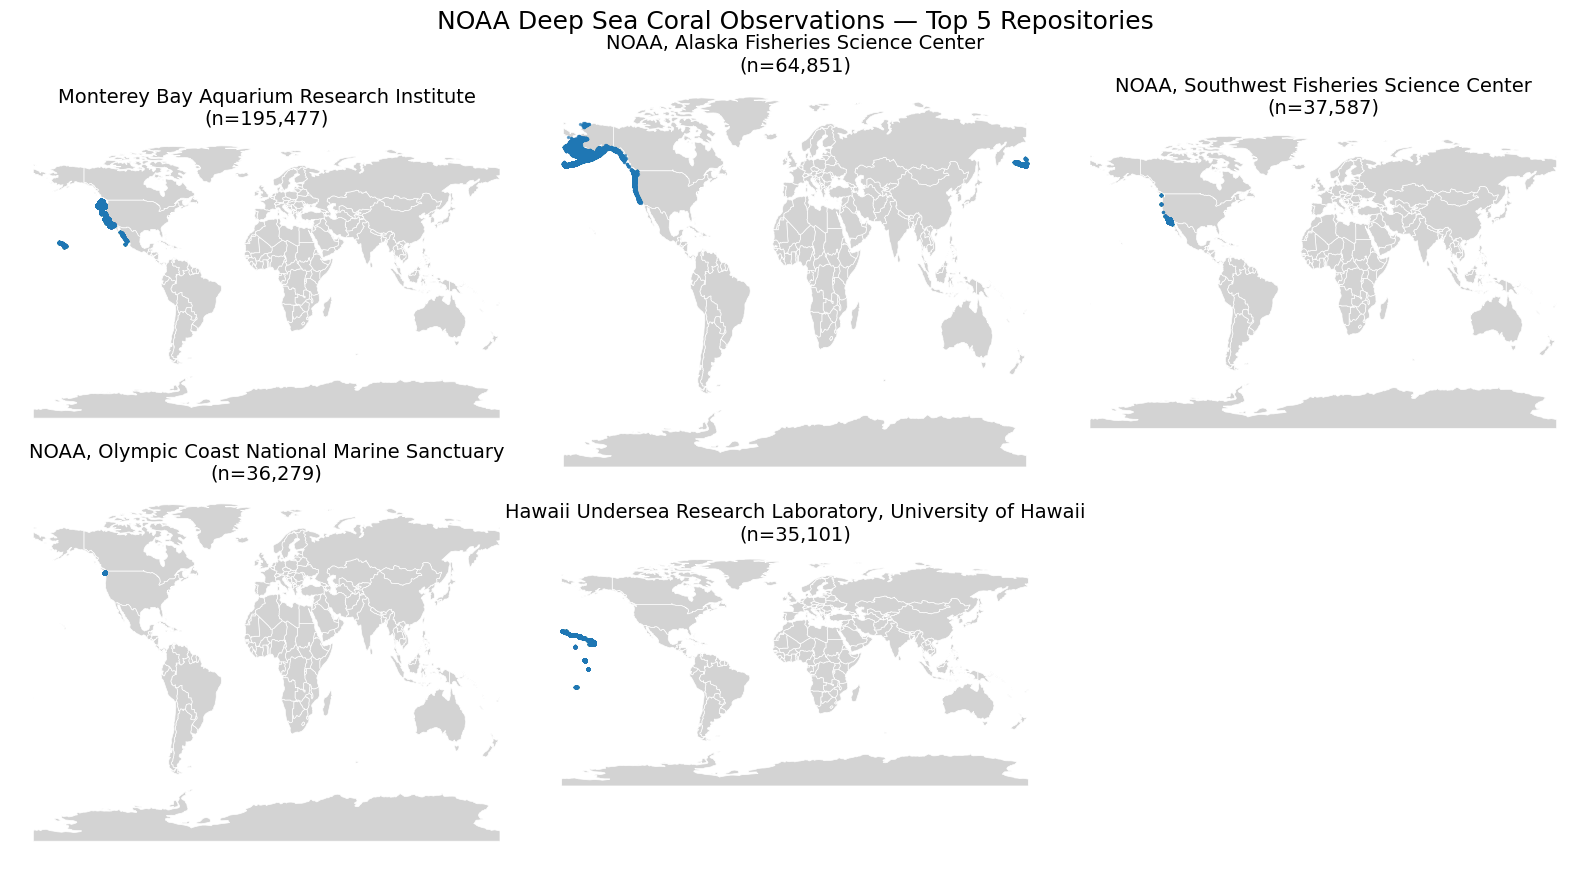

In [29]:

top5 = top5.tolist()

df_top = df[df["Repository"].isin(top5)].dropna(subset=["latitude", "longitude", "Repository"])

gdf = gpd.GeoDataFrame(
    df_top,
    geometry=gpd.points_from_xy(df_top["longitude"], df_top["latitude"]),
    crs="EPSG:4326"
)

#load world map
world = gpd.read_file("ne_110m_admin_0_countries.shp")
if world.crs is None:
    world = world.set_crs("EPSG:4326")
world = world.to_crs(gdf.crs)

#plot 5 maps
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, repo in enumerate(top5):
    ax = axes[i]
    world.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

    gdf[gdf["Repository"] == repo].plot(
        ax=ax,
        markersize=2,
        alpha=0.6
    )

    n = (df["Repository"] == repo).sum()
    ax.set_title(f"{repo}\n(n={n:,})", fontsize=14)
    ax.set_axis_off()

#hiding any unused subplot
for j in range(len(top5), len(axes)):
    axes[j].set_axis_off()

plt.suptitle("NOAA Deep Sea Coral Observations — Top 5 Repositories", fontsize=18)
plt.tight_layout()
plt.show()


Based on the information above, we think Hawaii might be a good fit. There is a lot of data and it covers enough space to resolve numerous distinct habitats but not too much that analysis will be challenging.

### Species Distribution

In [30]:
#counts for top 5 species in each repository
species_counts = (
    df_top
    .dropna(subset=["ScientificName"])
    .groupby(["Repository", "ScientificName"])
    .size()
    .reset_index(name="count")
)

#For each repository, keep only top 5 species
top_species_per_repo = (
    species_counts
    .sort_values(["Repository", "count"], ascending=[True, False])
    .groupby("Repository")
    .head(10)
)

top_species_per_repo


,Repository,ScientificName,count
139,"Hawaii Undersea Research Laboratory, Universit...",Kulamanamana haumeaae,2548
208,"Hawaii Undersea Research Laboratory, Universit...",Stichopathes sp.,1836
26,"Hawaii Undersea Research Laboratory, Universit...",Aphanipathes sp.,1650
123,"Hawaii Undersea Research Laboratory, Universit...",Isididae,1642
178,"Hawaii Undersea Research Laboratory, Universit...",Plexauridae,1321
81,"Hawaii Undersea Research Laboratory, Universit...",Corallium sp.,1319
80,"Hawaii Undersea Research Laboratory, Universit...",Corallium secundum,1205
38,"Hawaii Undersea Research Laboratory, Universit...",Calibelemnon symmetricum,982
143,"Hawaii Undersea Research Laboratory, Universit...",Lepidisis olapa,884
20,"Hawaii Undersea Research Laboratory, Universit...",Antipatharia,821


Looks like Hawaii has a decent distribution of different species.

### Depth Distribution

In [31]:
df["DepthInMeters"] = pd.to_numeric(df["DepthInMeters"], errors="coerce")

bin_width = 200
max_depth = df["DepthInMeters"].max()

bins = list(range(0, int(max_depth) + bin_width, bin_width))

df["DepthBin"] = pd.cut(df["DepthInMeters"], bins=bins)


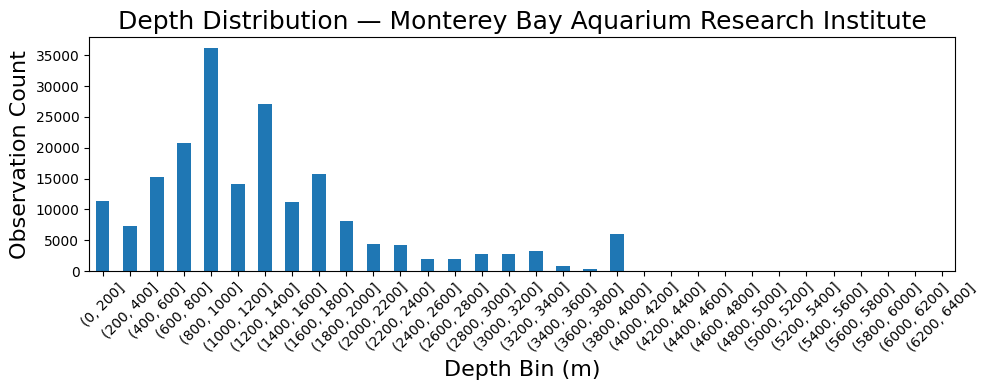

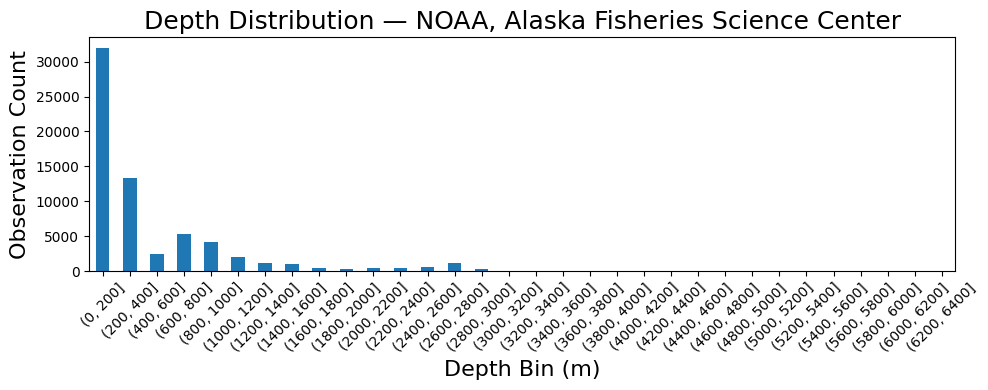

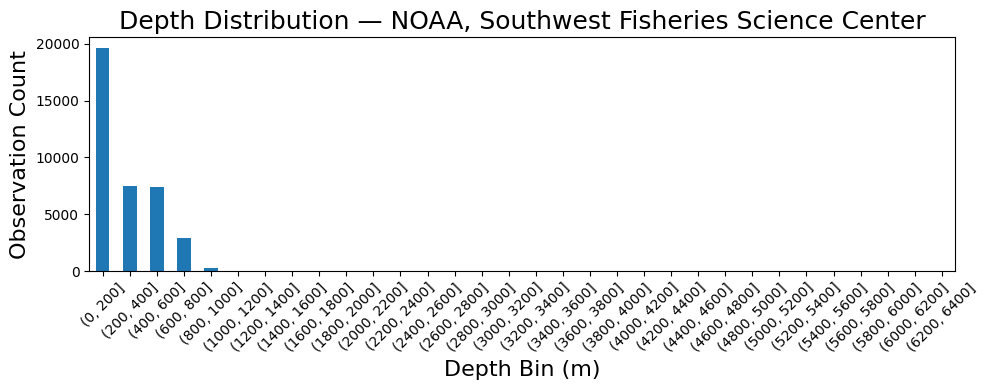

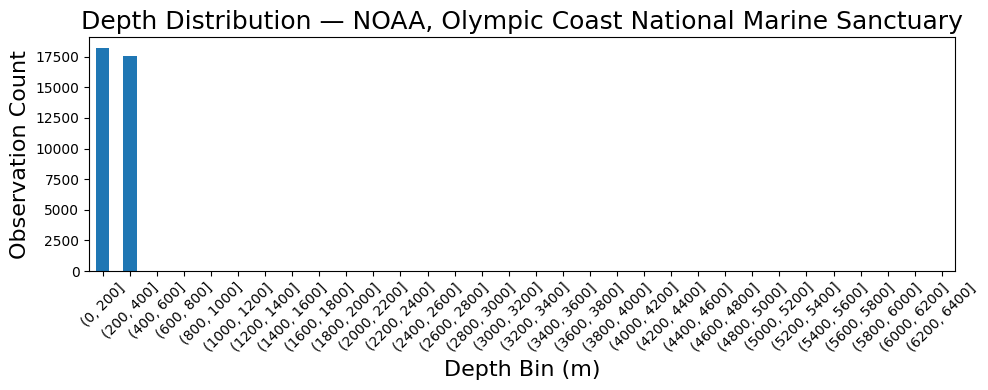

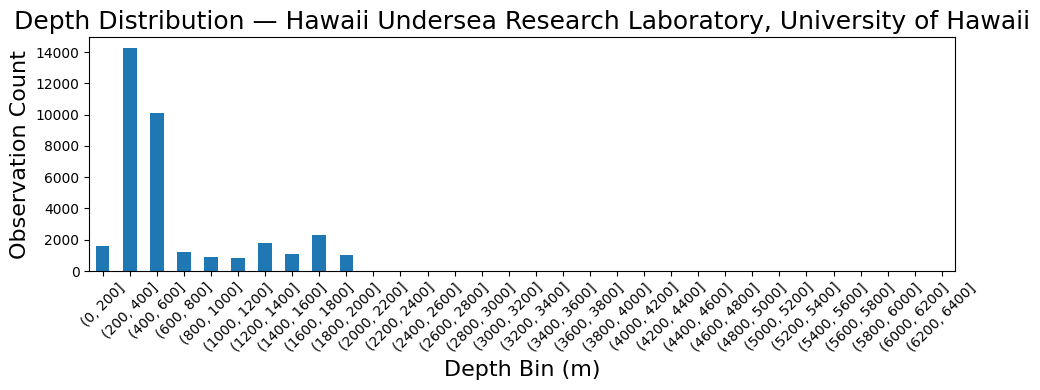

In [32]:
top5_repos = df["Repository"].dropna().value_counts().head(5).index.tolist()

for repo in top5_repos:
    subset = df[df["Repository"] == repo]

    counts = (
        subset["DepthBin"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(10,4))
    counts.plot(kind="bar")
    plt.title(f"Depth Distribution — {repo}", fontsize = 18)
    plt.xlabel("Depth Bin (m)", fontsize = 16)
    plt.ylabel("Observation Count", fontsize = 16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Hawaii also has a good distribution of depths. NOAA Olympic Coast and the Southwest Fisheries have a notable lack of depth range.

### Dates

In [33]:
df["ObservationDate"] = pd.to_datetime(df["ObservationDate"], errors="coerce")


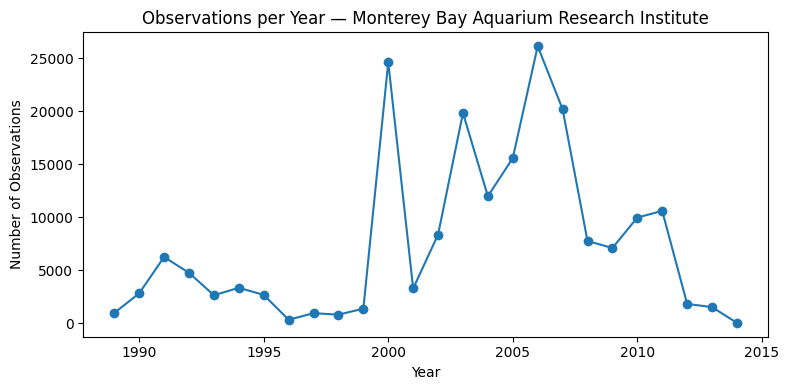

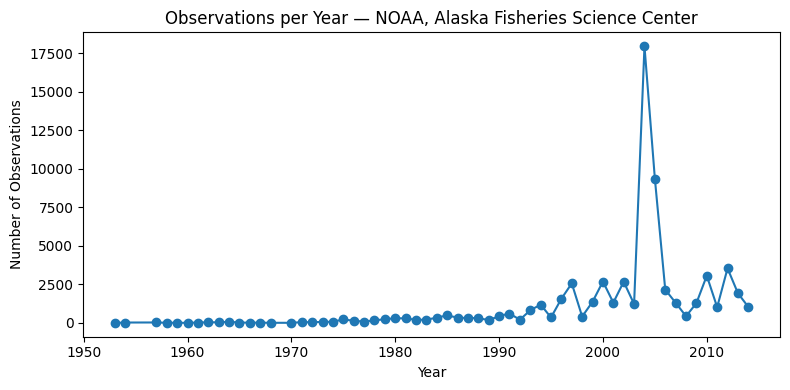

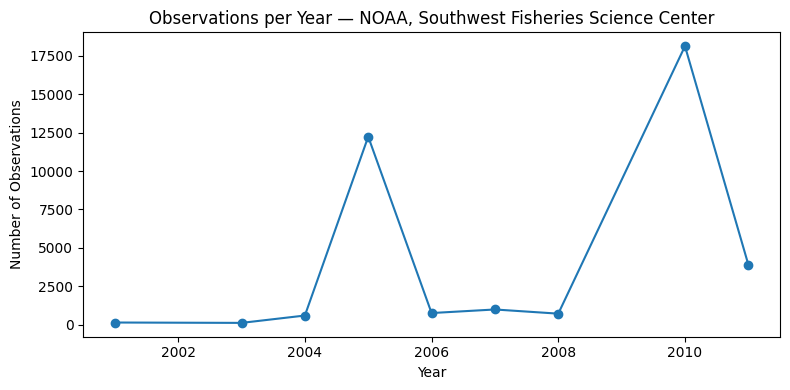

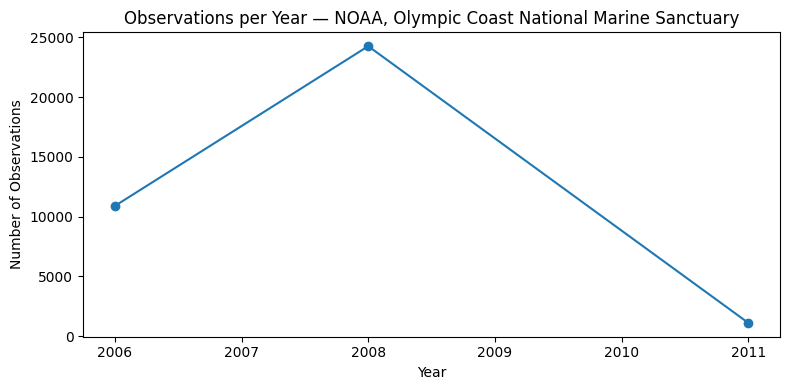

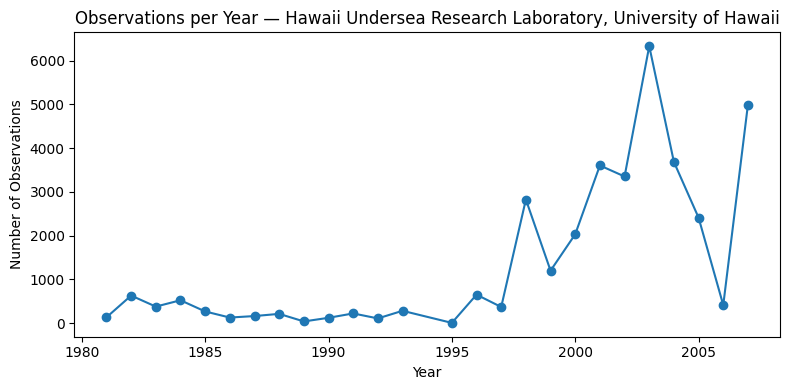

In [34]:
df["Year"] = df["ObservationDate"].dt.year

for repo in top5_repos:
    subset = df[df["Repository"] == repo]

    yearly_counts = subset.groupby("Year").size()

    plt.figure(figsize=(8,4))
    yearly_counts.plot(marker="o")
    plt.title(f"Observations per Year — {repo}")
    plt.xlabel("Year")
    plt.ylabel("Number of Observations")
    plt.tight_layout()
    plt.show()


We plan on starting our analysis with a fixed date range (we likely wouldn't be able to resolve changes in the number of anomolies over a short period of time), but we may want to compare anomolies across decades so we look for a data set where we could do this.

Hawaii is good for this, it has a solid distribution going back to 1980.

By examining the areas covered, species, depth, and dates, we choose to filter our data to only the Hawaii repository and use that for analysis.

## Hawaii Dataset Processing

In [35]:
hawaii = df[df["Repository"] == "Hawaii Undersea Research Laboratory, University of Hawaii"]

In [36]:
len(hawaii)

35101

In [37]:
hawaii.describe()

,CatalogNumber,ObservationDate,latitude,longitude,DepthInMeters,Year
count,35101.00000,35084,35101.000000,35101.000000,35101.000000,35084.000000
mean,514120.06826,2001-10-23 06:03:34.251510656,20.719376,-161.471760,630.058859,2001.058061
min,494904.00000,1981-12-15 00:00:00,-14.556840,-179.570980,28.000000,1981.000000
25%,504366.00000,2000-09-30 00:00:00,19.796470,-165.386980,358.000000,2000.000000
50%,513859.00000,2003-09-13 00:00:00,21.302780,-158.261070,411.000000,2003.000000
75%,523070.00000,2004-10-12 00:00:00,23.916730,-157.532500,649.000000,2004.000000
max,538543.00000,2007-12-11 00:00:00,28.969230,-154.800000,2377.000000,2007.000000
std,11509.19903,NaN,5.482579,5.925026,477.770754,5.690541


In [38]:
hawaii.head()

,CatalogNumber,DataProvider,ScientificName,VernacularNameCategory,TaxonRank,Station,ObservationDate,latitude,longitude,DepthInMeters,...,LocationAccuracy,SurveyID,Repository,IdentificationQualifier,EventID,SamplingEquipment,RecordType,SampleID,DepthBin,Year
27,537637.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,523.0,...,NaN,KOK 05-11,"Hawaii Undersea Research Laboratory, Universit...",ID by expert from video,P4-147,submersible,video observation,99311,"(400, 600]",2005.0
32,536917.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-146,2005-07-24,6.43462,-162.45311,1312.0,...,NaN,KOK 05-11,"Hawaii Undersea Research Laboratory, Universit...",ID by expert from video,P4-146,submersible,video observation,98417,"(1200, 1400]",2005.0
35,537636.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,523.0,...,NaN,KOK 05-11,"Hawaii Undersea Research Laboratory, Universit...",ID by expert from video,P4-147,submersible,video observation,99310,"(400, 600]",2005.0
40,536920.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-146,2005-07-24,6.43462,-162.45311,1312.0,...,NaN,KOK 05-11,"Hawaii Undersea Research Laboratory, Universit...",ID by expert from video,P4-146,submersible,video observation,98420,"(1200, 1400]",2005.0
43,537641.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,512.0,...,NaN,KOK 05-11,"Hawaii Undersea Research Laboratory, Universit...",ID by expert from video,P4-147,submersible,video observation,99315,"(400, 600]",2005.0


In [39]:
hawaii.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35101 entries, 27 to 511955
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CatalogNumber            35101 non-null  float64       
 1   DataProvider             35101 non-null  object        
 2   ScientificName           35101 non-null  object        
 3   VernacularNameCategory   35101 non-null  object        
 4   TaxonRank                35101 non-null  object        
 5   Station                  35101 non-null  object        
 6   ObservationDate          35084 non-null  datetime64[ns]
 7   latitude                 35101 non-null  float64       
 8   longitude                35101 non-null  float64       
 9   DepthInMeters            35101 non-null  float64       
 10  DepthMethod              35101 non-null  object        
 11  Locality                 35101 non-null  object        
 12  LocationAccuracy         32996 non-

In [40]:
print("Latitude range:")
print(hawaii["latitude"].min(), hawaii["latitude"].max())

print("Longitude range:")
print(hawaii["longitude"].min(), hawaii["longitude"].max())


Latitude range:
-14.55684 28.96923
Longitude range:
-179.57098 -154.8


Let's filter for dates that are not missing, this won't get rid of too many rows

In [41]:
hawaii = hawaii[hawaii["ObservationDate"].notna()]
hawaii.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35084 entries, 27 to 511955
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CatalogNumber            35084 non-null  float64       
 1   DataProvider             35084 non-null  object        
 2   ScientificName           35084 non-null  object        
 3   VernacularNameCategory   35084 non-null  object        
 4   TaxonRank                35084 non-null  object        
 5   Station                  35084 non-null  object        
 6   ObservationDate          35084 non-null  datetime64[ns]
 7   latitude                 35084 non-null  float64       
 8   longitude                35084 non-null  float64       
 9   DepthInMeters            35084 non-null  float64       
 10  DepthMethod              35084 non-null  object        
 11  Locality                 35084 non-null  object        
 12  LocationAccuracy         32979 non-

Let's get rid of the invalid depth variables

In [42]:
hawaii = hawaii[hawaii["DepthInMeters"] > 0].copy()

The WOA enviornment variable data is centered on a .25 degree grid (temp and salinity) and 1 degree grid (oxygen saturation) so we snap our coral data to those grids.

In [43]:
def snap_to_grid_25(x, step=0.25, offset=0.125):
    #snaps to centers like 18.125, 18.375, ...
    return np.round((x - offset) / step) * step + offset

In [44]:
#adding lat/lon .25 degree grid column values
hawaii["lat_025"] = snap_to_grid_25(hawaii["latitude"], step=0.25, offset=0.125)
hawaii["lon_025"] = snap_to_grid_25(hawaii["longitude"], step=0.25, offset=0.125)


In [45]:
#snapping to 1 degree grid
def snap_to_grid_1deg(x):
    return np.floor(x) + 0.5

In [46]:
#adding 1 degree columns
hawaii["lat_1"] = snap_to_grid_1deg(hawaii["latitude"])
hawaii["lon_1"] = snap_to_grid_1deg(hawaii["longitude"])

In [47]:
hawaii.head()

,CatalogNumber,DataProvider,ScientificName,VernacularNameCategory,TaxonRank,Station,ObservationDate,latitude,longitude,DepthInMeters,...,EventID,SamplingEquipment,RecordType,SampleID,DepthBin,Year,lat_025,lon_025,lat_1,lon_1
27,537637.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,523.0,...,P4-147,submersible,video observation,99311,"(400, 600]",2005.0,5.875,-162.125,5.5,-162.5
32,536917.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-146,2005-07-24,6.43462,-162.45311,1312.0,...,P4-146,submersible,video observation,98417,"(1200, 1400]",2005.0,6.375,-162.375,6.5,-162.5
35,537636.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,523.0,...,P4-147,submersible,video observation,99310,"(400, 600]",2005.0,5.875,-162.125,5.5,-162.5
40,536920.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-146,2005-07-24,6.43462,-162.45311,1312.0,...,P4-146,submersible,video observation,98420,"(1200, 1400]",2005.0,6.375,-162.375,6.5,-162.5
43,537641.0,Hawaii Undersea Research Laboratory,Madrepora oculata,stony coral (branching),species,P4-147,2005-07-25,5.90687,-162.13856,512.0,...,P4-147,submersible,video observation,99315,"(400, 600]",2005.0,5.875,-162.125,5.5,-162.5


# Analyzing NOAA Data

In [48]:
drive.mount('/content/drive')


Mounted at /content/drive


In [49]:

os.listdir("/content/drive/Shareddrives/")

['Leadership and Consulting Team', 'ML Final Project']

In [50]:
data_path = "/content/drive/Shareddrives/ML Final Project/Data/"

## Reading the file

This function below is to read in the WOA files and create cleaned CSVs

In [53]:
import gzip
import pandas as pd

def read_woa_wide_clean_subset(
    in_path: str,
    out_path: str = None,
    lat_min=-15, lat_max=29,
    lon_min=-180, lon_max=-153,
    max_depth=1800,
    var_prefix = "temp"
):
    opener = gzip.open if in_path.endswith(".gz") else open

    depth_list = None
    rows = []

    with opener(in_path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            if not line.strip():
                continue

            if line.lstrip().startswith("#COMMA SEPARATED LATITUDE"):
                depth_str = line.split(":", 1)[1].strip()
                depth_list = [float(x) for x in depth_str.split(",") if x != ""]
                continue

            if line.lstrip().startswith("#"):
                continue

            line = line.strip().rstrip(",")
            parts = line.split(",")

            if len(parts) < 3:
                continue

            try:
                lat = float(parts[0])
                lon = float(parts[1])
            except ValueError:
                continue

            if not (lat_min <= lat <= lat_max and lon_min <= lon <= lon_max):
                continue

            if depth_list is None:
                continue

            rec = {"lat": lat, "lon": lon}

            for j, d in enumerate(depth_list):
                if d > max_depth:
                    continue

                idx = 2 + j
                val = parts[idx] if idx < len(parts) else ""
                rec[f"{var_prefix}_{int(d)}m"] = pd.to_numeric(val, errors="coerce")

            rows.append(rec)

    out_df = pd.DataFrame(rows)

    if out_path:
        out_df.to_csv(out_path, index=False)
        print("Saved cleaned subset to:", out_path)

    return out_df


## Cleaning the WOA Temperature File

In [54]:
temp_path = data_path + "woa23_decav91C0_t00mn04.csv.gz"


In [55]:
#using the function
woa_temp = read_woa_wide_clean_subset(
    temp_path,
    out_path="/content/drive/Shareddrives/ML Final Project/Data/woa_temp_hawaii_subset.csv",
    max_depth=1800,
    var_prefix = "temp"
)

print(woa_temp.shape)
woa_temp.head()


Saved cleaned subset to: /content/drive/Shareddrives/ML Final Project/Data/woa_temp_hawaii_subset.csv
(18535, 65)


,lat,lon,temp_0m,temp_5m,temp_10m,temp_15m,temp_20m,temp_25m,temp_30m,temp_35m,...,temp_1350m,temp_1400m,temp_1450m,temp_1500m,temp_1550m,temp_1600m,temp_1650m,temp_1700m,temp_1750m,temp_1800m
0,-14.875,-179.875,28.708,28.731,28.689,28.661,28.652,28.651,28.651,28.605,...,2.995,2.923,2.851,2.773,2.712,2.646,2.586,2.529,2.455,2.403
1,-14.875,-179.625,28.961,28.942,28.925,28.906,28.885,28.880,28.876,28.874,...,3.052,2.987,2.935,2.846,2.780,2.732,2.680,2.634,2.587,2.522
2,-14.875,-179.375,28.649,28.862,28.852,28.806,28.769,28.735,28.724,28.668,...,3.094,3.035,2.929,2.854,2.787,2.693,2.637,2.591,NaN,NaN
3,-14.875,-179.125,28.708,28.711,28.627,28.595,28.540,28.547,28.543,28.540,...,3.059,2.965,2.910,2.843,2.785,2.727,2.684,2.612,2.555,2.483
4,-14.875,-178.875,29.041,29.073,29.070,29.074,29.077,29.069,29.062,29.059,...,3.156,3.044,2.958,2.876,2.819,2.762,2.720,2.675,2.627,2.561


# Saving 1000 row sample

In [56]:
df_1000_woaa = woa_temp.head(1000)
len(df_1000_woaa)

1000

In [57]:
df_1000_woaa.to_csv("woaa_sample_1000.csv", index=False)

In [58]:
files.download("woaa_sample_1000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
woa_temp.describe()

,lat,lon,temp_0m,temp_5m,temp_10m,temp_15m,temp_20m,temp_25m,temp_30m,temp_35m,...,temp_1350m,temp_1400m,temp_1450m,temp_1500m,temp_1550m,temp_1600m,temp_1650m,temp_1700m,temp_1750m,temp_1800m
count,18535.000000,18535.000000,18267.000000,18255.000000,18513.000000,18518.000000,18516.000000,18515.000000,18517.000000,18518.000000,...,16115.000000,16110.000000,16079.000000,15799.000000,15760.000000,15746.000000,15699.000000,15666.000000,15646.000000,15610.000000
mean,6.905483,-166.470279,27.518625,27.527154,27.503020,27.483843,27.464632,27.436930,27.406346,27.360196,...,3.284343,3.160012,3.042904,2.931612,2.826837,2.729659,2.640422,2.557533,2.481280,2.409920
std,12.661702,7.799559,1.698518,1.698745,1.688479,1.696809,1.708721,1.727258,1.754126,1.794944,...,0.167143,0.156506,0.146309,0.137719,0.129478,0.122186,0.115826,0.110686,0.106112,0.102526
min,-14.875000,-179.875000,18.614000,18.103000,18.681000,18.682000,18.683000,18.684000,18.686000,18.693000,...,2.692000,2.611000,2.537000,2.456000,2.376000,2.303000,2.241000,2.171000,2.114000,2.052000
25%,-4.125000,-173.125000,26.532500,26.543000,26.537000,26.519000,26.501000,26.474500,26.442000,26.394000,...,3.200000,3.082000,2.971000,2.863000,2.763000,2.669000,2.582000,2.502000,2.426250,2.356000
50%,6.875000,-166.375000,27.880000,27.890000,27.876000,27.861000,27.848500,27.826000,27.802000,27.771500,...,3.322000,3.192000,3.070000,2.954000,2.845000,2.745000,2.654000,2.571000,2.494000,2.422000
75%,17.875000,-159.625000,28.807000,28.820000,28.804000,28.789000,28.778000,28.765000,28.750000,28.729000,...,3.404500,3.273000,3.147000,3.031000,2.921000,2.819000,2.726000,2.640000,2.561000,2.487000
max,28.875000,-153.125000,30.695000,30.569000,30.587000,30.590000,30.586000,30.588000,30.590000,30.589000,...,3.716000,3.571000,3.434000,3.316000,3.195000,3.060000,2.961000,2.869000,2.769000,2.679000


## Cleaning the WOA Salinity File

In [60]:
salin_path = data_path + "woa23_decav91C0_s00mn04.csv.gz"

In [61]:
print(salin_path)

/content/drive/Shareddrives/ML Final Project/Data/woa23_decav91C0_s00mn04.csv.gz


In [62]:
#using the function
woa_salin = read_woa_wide_clean_subset(
    salin_path,
    out_path="/content/drive/Shareddrives/ML Final Project/Data/woa_salinity_hawaii_subset.csv",
    max_depth=1800,
    var_prefix = "salin"
)

print(woa_salin.shape)
woa_salin.head()


Saved cleaned subset to: /content/drive/Shareddrives/ML Final Project/Data/woa_salinity_hawaii_subset.csv
(17924, 65)


,lat,lon,salin_0m,salin_5m,salin_10m,salin_15m,salin_20m,salin_25m,salin_30m,salin_35m,...,salin_1350m,salin_1400m,salin_1450m,salin_1500m,salin_1550m,salin_1600m,salin_1650m,salin_1700m,salin_1750m,salin_1800m
0,-14.875,-179.875,35.152,35.599,35.599,35.598,35.596,35.593,35.591,35.591,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-14.875,-179.625,35.091,35.240,35.241,35.241,35.240,35.253,35.287,35.324,...,34.563,34.571,34.575,34.580,34.586,34.589,34.593,34.598,34.602,34.607
2,-14.875,-179.375,35.253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-14.875,-179.125,34.941,NaN,34.252,34.254,34.257,34.257,34.256,34.260,...,34.557,34.564,34.571,34.578,34.583,34.589,34.594,34.598,34.604,34.610
4,-14.875,-178.875,35.020,34.790,34.593,34.605,34.614,34.687,34.723,34.769,...,34.560,34.567,34.574,34.579,34.584,34.589,34.592,34.597,34.601,34.607


In [63]:
woa_salin.describe()

,lat,lon,salin_0m,salin_5m,salin_10m,salin_15m,salin_20m,salin_25m,salin_30m,salin_35m,...,salin_1350m,salin_1400m,salin_1450m,salin_1500m,salin_1550m,salin_1600m,salin_1650m,salin_1700m,salin_1750m,salin_1800m
count,17924.000000,17924.000000,17182.000000,16894.000000,17734.000000,17752.000000,17753.000000,17754.000000,17756.000000,17758.000000,...,15566.000000,15556.000000,15530.000000,15217.000000,15183.000000,15169.000000,15124.000000,15099.000000,15079.000000,15054.000000
mean,6.716609,-166.415895,35.008319,35.014429,35.029661,35.032664,35.036636,35.041926,35.049062,35.058634,...,34.571331,34.577413,34.583256,34.588778,34.594218,34.599442,34.604399,34.609126,34.613588,34.617908
std,12.620374,7.824154,0.444615,0.447975,0.441302,0.440631,0.438749,0.436462,0.432850,0.427537,...,0.020387,0.018520,0.017069,0.015821,0.014769,0.013856,0.013073,0.012347,0.011752,0.011203
min,-14.875000,-179.875000,33.317000,33.440000,33.378000,33.358000,33.530000,33.544000,33.562000,33.665000,...,34.469000,34.490000,34.501000,34.518000,34.533000,34.543000,34.552000,34.561000,34.567000,34.573000
25%,-4.125000,-173.125000,34.656000,34.657000,34.680000,34.684000,34.690000,34.696000,34.704000,34.716000,...,34.563000,34.569000,34.575000,34.581000,34.586000,34.592000,34.597000,34.602000,34.606000,34.611000
50%,6.625000,-166.375000,35.071000,35.078000,35.096000,35.100000,35.104000,35.109000,35.116000,35.124000,...,34.577000,34.583000,34.588000,34.593000,34.598000,34.603000,34.608000,34.613000,34.617000,34.621000
75%,17.625000,-159.625000,35.364000,35.370000,35.380000,35.382000,35.384000,35.386000,35.389000,35.392000,...,34.587000,34.592000,34.597000,34.601000,34.606000,34.610000,34.615000,34.619000,34.623000,34.626000
max,28.875000,-153.125000,36.306000,36.307000,36.336000,36.336000,36.336000,36.336000,36.336000,36.336000,...,34.607000,34.610000,34.614000,34.619000,34.622000,34.626000,34.631000,34.635000,34.640000,34.643000


## Cleaning the WOA Dissolved Oxygen File

In [64]:
ox_path = data_path + "woa23_decav71A0_O00mn01.csv.gz"

In [65]:
print(ox_path)

/content/drive/Shareddrives/ML Final Project/Data/woa23_decav71A0_O00mn01.csv.gz


In [66]:
#using the function
woa_ox = read_woa_wide_clean_subset(
    ox_path,
    out_path="/content/drive/Shareddrives/ML Final Project/Data/woa_oxygen_hawaii_subset.csv",
    max_depth=1800,
    var_prefix = "ox_sat"
)

print(woa_ox.shape)
woa_ox.head()

Saved cleaned subset to: /content/drive/Shareddrives/ML Final Project/Data/woa_oxygen_hawaii_subset.csv
(587, 65)


,lat,lon,ox_sat_0m,ox_sat_5m,ox_sat_10m,ox_sat_15m,ox_sat_20m,ox_sat_25m,ox_sat_30m,ox_sat_35m,...,ox_sat_1350m,ox_sat_1400m,ox_sat_1450m,ox_sat_1500m,ox_sat_1550m,ox_sat_1600m,ox_sat_1650m,ox_sat_1700m,ox_sat_1750m,ox_sat_1800m
0,-14.5,-179.5,102.019,102.317,101.965,102.050,102.760,102.795,102.697,102.589,...,45.074,45.010,45.039,45.048,45.177,44.930,44.937,44.755,44.501,44.590
1,-14.5,-178.5,101.308,100.568,100.654,100.741,101.110,101.729,102.527,102.279,...,44.914,44.717,44.790,44.046,43.940,43.987,43.956,43.990,43.797,43.860
2,-14.5,-177.5,104.093,103.444,103.127,102.763,102.260,102.196,101.630,101.928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-14.5,-176.5,104.354,104.652,104.260,104.185,104.420,104.274,103.721,103.861,...,45.722,45.344,45.598,45.429,44.690,44.751,44.786,45.112,44.850,44.854
4,-14.5,-174.5,102.290,102.534,102.810,103.003,103.006,102.661,101.923,101.609,...,45.250,45.193,45.166,45.064,45.068,45.061,45.004,44.920,44.828,44.858


In [67]:
woa_ox.describe()

,lat,lon,ox_sat_0m,ox_sat_5m,ox_sat_10m,ox_sat_15m,ox_sat_20m,ox_sat_25m,ox_sat_30m,ox_sat_35m,...,ox_sat_1350m,ox_sat_1400m,ox_sat_1450m,ox_sat_1500m,ox_sat_1550m,ox_sat_1600m,ox_sat_1650m,ox_sat_1700m,ox_sat_1750m,ox_sat_1800m
count,587.000000,587.000000,528.000000,512.000000,550.000000,557.000000,559.000000,558.000000,559.000000,559.000000,...,234.000000,224.000000,164.000000,169.000000,183.000000,184.000000,185.000000,151.00000,145.000000,177.000000
mean,6.138842,-165.276831,101.474807,101.586666,101.737920,101.694641,101.685392,101.552921,101.521585,101.497386,...,27.580427,28.315821,29.943268,30.483982,30.448481,30.909625,31.419897,32.78296,33.435083,32.850655
std,12.895182,8.047615,2.914983,2.866741,2.874548,2.565299,2.600830,2.629482,2.692274,2.820594,...,8.906800,8.720929,9.314308,8.993885,8.553833,8.329321,8.173450,8.27512,8.080286,7.502141
min,-14.500000,-179.500000,87.444000,92.036000,91.013000,92.567000,92.009000,90.603000,91.199000,89.306000,...,15.342000,16.532000,17.401000,17.059000,19.797000,20.440000,21.047000,22.02700,22.535000,22.557000
25%,-4.500000,-171.500000,99.960250,100.089750,100.380000,100.413000,100.266500,99.917000,100.050000,99.884000,...,20.302250,21.251750,21.367750,22.222000,22.760500,23.491250,24.080000,24.81850,25.462000,26.153000
50%,4.500000,-164.500000,101.562000,101.649500,101.800000,101.818000,101.878000,101.775000,101.847000,101.782000,...,23.499000,24.382500,25.474000,26.053000,26.505000,27.095000,27.848000,28.78100,29.644000,29.609000
75%,17.500000,-158.500000,102.972750,103.043000,103.265250,103.172000,103.165000,103.075500,103.031000,103.126000,...,38.566750,39.312750,40.531250,41.002000,41.102500,41.331750,41.654000,42.00650,42.155000,42.043000
max,28.500000,-153.500000,112.698000,114.341000,110.614000,110.830000,111.383000,111.827000,112.162000,112.387000,...,45.722000,45.344000,45.598000,45.429000,45.177000,45.061000,45.004000,45.11200,44.850000,44.858000


## Converting Enviornmental Dataframes to Long Format

In [68]:

def woa_wide_to_long(df_wide: pd.DataFrame, prefix: str, value_name: str = None) -> pd.DataFrame:
    """
    Converts a WOA 'wide' df like:
        lat, lon, temp_0m, temp_5m, ..., temp_1800m
    into a long df like:
        lat, lon, depth_m, temp
    """
    if value_name is None:
        value_name = prefix

    value_cols = [c for c in df_wide.columns if c.startswith(prefix + "_") and c.endswith("m")]
    if not value_cols:
        raise ValueError(f"No columns found for prefix='{prefix}'. Check column names.")

    long = df_wide.melt(
        id_vars=["lat", "lon"],
        value_vars=value_cols,
        var_name="depth_col",
        value_name=value_name
    )

    #depth_m extracted
    long["depth_m"] = long["depth_col"].str.extract(r"_(\d+)m").astype("Int64")
    long = long.drop(columns=["depth_col"])

    long = long.dropna(subset=[value_name])

    return long


In [69]:
temp_long  = woa_wide_to_long(woa_temp,  prefix="temp",   value_name="temp")
salin_long = woa_wide_to_long(woa_salin, prefix="salin",  value_name="salin")
ox_long    = woa_wide_to_long(woa_ox,    prefix="ox_sat", value_name="ox_sat")

print(temp_long.shape, salin_long.shape, ox_long.shape)


(1125283, 4) (1081914, 4) (24645, 4)


In [70]:
temp_long.head()

,lat,lon,temp,depth_m
0,-14.875,-179.875,28.708,0
1,-14.875,-179.625,28.961,0
2,-14.875,-179.375,28.649,0
3,-14.875,-179.125,28.708,0
4,-14.875,-178.875,29.041,0


In [71]:
salin_long.head()

,lat,lon,salin,depth_m
0,-14.875,-179.875,35.152,0
1,-14.875,-179.625,35.091,0
2,-14.875,-179.375,35.253,0
3,-14.875,-179.125,34.941,0
4,-14.875,-178.875,35.020,0


In [72]:
ox_long.head()

,lat,lon,ox_sat,depth_m
0,-14.5,-179.5,102.019,0
1,-14.5,-178.5,101.308,0
2,-14.5,-177.5,104.093,0
3,-14.5,-176.5,104.354,0
4,-14.5,-174.5,102.290,0


# Merging Coral with WOA Data

In [73]:
#rename WOA columns to match grid
woa_temp_025  = woa_temp.rename(columns={"lat": "lat_025", "lon": "lon_025"})
woa_salin_025 = woa_salin.rename(columns={"lat": "lat_025", "lon": "lon_025"})
woa_ox_1      = woa_ox.rename(columns={"lat": "lat_1",   "lon": "lon_1"})

#merge temp and salinity to one environmental table
env_025 = pd.merge(
    woa_temp_025,
    woa_salin_025,
    on=["lat_025", "lon_025"],
    how="inner"
)

print("env_025 shape:", env_025.shape)
env_025.head()


env_025 shape: (17849, 128)


,lat_025,lon_025,temp_0m,temp_5m,temp_10m,temp_15m,temp_20m,temp_25m,temp_30m,temp_35m,...,salin_1350m,salin_1400m,salin_1450m,salin_1500m,salin_1550m,salin_1600m,salin_1650m,salin_1700m,salin_1750m,salin_1800m
0,-14.875,-179.875,28.708,28.731,28.689,28.661,28.652,28.651,28.651,28.605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-14.875,-179.625,28.961,28.942,28.925,28.906,28.885,28.880,28.876,28.874,...,34.563,34.571,34.575,34.580,34.586,34.589,34.593,34.598,34.602,34.607
2,-14.875,-179.375,28.649,28.862,28.852,28.806,28.769,28.735,28.724,28.668,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-14.875,-179.125,28.708,28.711,28.627,28.595,28.540,28.547,28.543,28.540,...,34.557,34.564,34.571,34.578,34.583,34.589,34.594,34.598,34.604,34.610
4,-14.875,-178.875,29.041,29.073,29.070,29.074,29.077,29.069,29.062,29.059,...,34.560,34.567,34.574,34.579,34.584,34.589,34.592,34.597,34.601,34.607


Nowe we build a combined .25 grid enviornmental data table

In [74]:
env_025_long = pd.merge(
    temp_long,
    salin_long,
    on=["lat", "lon", "depth_m"],
    how="inner"
)

print("env_025_long shape:", env_025_long.shape)
env_025_long.head()


env_025_long shape: (1074661, 5)


,lat,lon,temp,depth_m,salin
0,-14.875,-179.875,28.708,0,35.152
1,-14.875,-179.625,28.961,0,35.091
2,-14.875,-179.375,28.649,0,35.253
3,-14.875,-179.125,28.708,0,34.941
4,-14.875,-178.875,29.041,0,35.020


In [75]:
print(temp_long[["lat","lon","depth_m"]].drop_duplicates().shape,
      salin_long[["lat","lon","depth_m"]].drop_duplicates().shape,
      env_025_long[["lat","lon","depth_m"]].drop_duplicates().shape)


(1125283, 3) (1081914, 3) (1074661, 3)


Now we snap coral depth to the nearest WOA depth

In [76]:
print("Max coral depth:", hawaii["DepthInMeters"].max())


Max coral depth: 2377.0


Filtering the coral depth to less than 1800 to align with WOA dataset

In [77]:
hawaii = hawaii[
    (hawaii["DepthInMeters"] > 0) &
    (hawaii["DepthInMeters"] <= 1800)
]

In [78]:
levels_025 = np.sort(env_025_long["depth_m"].dropna().unique())
levels_1   = np.sort(ox_long["depth_m"].dropna().unique())

def snap_depth_to_levels(depth_series, levels):
    d = depth_series.to_numpy()
    idx = np.abs(levels[None, :] - d[:, None]).argmin(axis=1)
    return levels[idx]

hawaii = hawaii.copy()
hawaii["depth_m_025"] = snap_depth_to_levels(hawaii["DepthInMeters"], levels_025)
hawaii["depth_m_1"]   = snap_depth_to_levels(hawaii["DepthInMeters"], levels_1)


Computing snapping error

In [79]:
hawaii["snap_error_025"] = hawaii["DepthInMeters"] - hawaii["depth_m_025"]
hawaii["snap_error_1"]   = hawaii["DepthInMeters"] - hawaii["depth_m_1"]


In [80]:
print("0.25° grid depth snap error:")
print(hawaii["snap_error_025"].abs().describe())

print("\n1° grid depth snap error:")
print(hawaii["snap_error_1"].abs().describe())


0.25° grid depth snap error:
count    34070.000000
mean         7.449633
std          5.860624
min          0.000000
25%          3.000000
50%          7.000000
75%         11.000000
max         25.000000
Name: snap_error_025, dtype: float64

1° grid depth snap error:
count    34070.000000
mean         7.449633
std          5.860624
min          0.000000
25%          3.000000
50%          7.000000
75%         11.000000
max         25.000000
Name: snap_error_1, dtype: float64


Everything looks good here (we checked because they depth grid was more coarse)

Now we prepare the enviornmental tables to merge

In [81]:
#preparing lat and log keys to match
env_025_long_keyed = env_025_long.rename(columns={
    "lat": "lat_025",
    "lon": "lon_025",
    "depth_m": "depth_m_025"
})

#preparing oxygen keys to match
ox_long_keyed = ox_long.rename(columns={
    "lat": "lat_1",
    "lon": "lon_1",
    "depth_m": "depth_m_1"
})


In [82]:
# adding year for hawaii
hawaii["Year"] = hawaii["ObservationDate"].dt.year

In [83]:
#merging enviornmental variables onto coral dataset
hawaii_env = pd.merge(
    hawaii,
    env_025_long_keyed[["lat_025", "lon_025", "depth_m_025", "temp", "salin"]],
    on=["lat_025", "lon_025", "depth_m_025"],
    how="left"
)

In [84]:
hawaii_env = pd.merge(
    hawaii_env,
    ox_long_keyed[["lat_1", "lon_1", "depth_m_1", "ox_sat"]],
    on=["lat_1", "lon_1", "depth_m_1"],
    how="left"
)


In [85]:
hawaii_env.describe()

,CatalogNumber,ObservationDate,latitude,longitude,DepthInMeters,Year,lat_025,lon_025,lat_1,lon_1,depth_m_025,depth_m_1,snap_error_025,snap_error_1,temp,salin,ox_sat
count,34070.000000,34070,34070.000000,34070.000000,34070.000000,34070.000000,34070.000000,34070.000000,34070.000000,34070.000000,34070.00000,34070.00000,34070.000000,34070.000000,17657.000000,17657.000000,13251.000000
mean,514216.359701,2001-11-17 03:13:27.067801600,20.684085,-161.459118,593.734429,2001.125829,20.674633,-161.483233,20.593719,-161.517200,593.41899,593.41899,0.315439,0.315439,8.030384,34.309122,46.444665
min,494904.000000,1981-12-15 00:00:00,-14.556840,-179.570980,28.000000,1981.000000,-14.625000,-179.625000,-14.500000,-179.500000,30.00000,30.00000,-24.000000,-24.000000,2.137000,34.052000,9.081000
25%,504067.250000,2000-10-01 00:00:00,19.796780,-165.386900,356.000000,2000.000000,19.875000,-165.375000,19.500000,-165.500000,350.00000,350.00000,-7.000000,-7.000000,5.587000,34.146000,28.346000
50%,513968.500000,2003-09-18 00:00:00,21.303330,-158.261070,408.000000,2003.000000,21.375000,-158.375000,21.500000,-158.500000,400.00000,400.00000,0.000000,0.000000,8.356000,34.212000,47.567000
75%,523338.750000,2004-10-14 00:00:00,23.916580,-157.535300,565.000000,2004.000000,23.875000,-157.625000,23.500000,-157.500000,550.00000,550.00000,7.000000,7.000000,9.503000,34.522000,65.888000
max,538543.000000,2007-12-11 00:00:00,28.969230,-154.800000,1800.000000,2007.000000,28.875000,-154.875000,28.500000,-154.500000,1800.00000,1800.00000,25.000000,25.000000,27.000000,35.330000,107.823000
std,11642.039489,NaN,5.539203,5.848069,434.799474,5.711261,5.540816,5.839188,5.560407,5.833906,434.10031,434.10031,9.473440,9.473440,3.834725,0.220345,21.246114


In [86]:
hawaii_env.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34070 entries, 0 to 34069
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CatalogNumber            34070 non-null  float64       
 1   DataProvider             34070 non-null  object        
 2   ScientificName           34070 non-null  object        
 3   VernacularNameCategory   34070 non-null  object        
 4   TaxonRank                34070 non-null  object        
 5   Station                  34070 non-null  object        
 6   ObservationDate          34070 non-null  datetime64[ns]
 7   latitude                 34070 non-null  float64       
 8   longitude                34070 non-null  float64       
 9   DepthInMeters            34070 non-null  float64       
 10  DepthMethod              34070 non-null  object        
 11  Locality                 34070 non-null  object        
 12  LocationAccuracy         31965 n

# Refining Final Clustering Dataset

Let's filter the dataset to only include rows that have enviornmental variables for all columns we're interested in

In [87]:
hawaii_subset = hawaii_env.dropna(subset=["temp", "salin", "ox_sat"]).copy()


In [88]:
hawaii_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10477 entries, 21 to 34069
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CatalogNumber            10477 non-null  float64       
 1   DataProvider             10477 non-null  object        
 2   ScientificName           10477 non-null  object        
 3   VernacularNameCategory   10477 non-null  object        
 4   TaxonRank                10477 non-null  object        
 5   Station                  10477 non-null  object        
 6   ObservationDate          10477 non-null  datetime64[ns]
 7   latitude                 10477 non-null  float64       
 8   longitude                10477 non-null  float64       
 9   DepthInMeters            10477 non-null  float64       
 10  DepthMethod              10477 non-null  object        
 11  Locality                 10477 non-null  object        
 12  LocationAccuracy         9942 non-nu

Including only the subset of columns relevant to us

In [89]:
final_df = hawaii_subset[["ScientificName", "latitude", "longitude", "Year", "DepthInMeters", "temp", "salin", "ox_sat"]]
final_df.head()


,ScientificName,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat
21,Stichopathes sp.,18.94637,-155.71550,2002,165.0,19.245,34.881,83.342
24,Stichopathes sp.,18.94637,-155.71550,2002,135.0,22.417,35.105,94.884
26,Stichopathes sp.,24.57055,-167.31575,2003,211.0,16.923,34.781,84.844
38,Stichopathes sp.,23.26355,-162.99783,2003,364.0,10.695,34.175,73.659
52,Stichopathes sp.,24.57055,-167.31575,2003,211.0,16.923,34.781,84.844


We restrict to year greater than 2000 to have a more recent subset of data

In [90]:
final_df = final_df[final_df["Year"] >= 2000]

In [91]:
final_df.describe()

,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat
count,8968.000000,8968.000000,8968.000000,8968.000000,8968.000000,8968.000000,8968.000000
mean,19.065625,-159.937140,2003.270963,572.086976,7.925607,34.286454,41.792885
std,6.617181,5.317693,2.367477,385.516246,2.921280,0.189098,19.046701
min,-14.218710,-179.570980,2000.000000,59.000000,2.409000,34.065000,9.153000
25%,18.732000,-160.024105,2001.000000,387.000000,7.489000,34.162000,24.585000
50%,19.628330,-158.261500,2003.000000,405.000000,8.356000,34.212000,40.069000
75%,21.618630,-156.128900,2005.000000,497.000000,8.910000,34.403000,54.099000
max,28.969230,-155.240850,2007.000000,1771.000000,25.629000,35.216000,104.023000


In [92]:
final_df = final_df.drop_duplicates().reset_index(drop=True)

In [93]:
final_df.describe()


,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat
count,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,17.758806,-160.030245,2003.325156,566.565610,7.954181,34.310337,40.444944
std,8.166801,4.938811,2.424038,366.773002,2.890395,0.201018,19.526319
min,-14.218710,-179.570980,2000.000000,59.000000,2.409000,34.065000,9.153000
25%,18.728550,-160.024290,2001.000000,387.000000,7.474000,34.162000,23.285000
50%,18.973500,-158.261700,2004.000000,409.000000,8.356000,34.212000,40.069000
75%,21.616670,-156.134130,2005.000000,503.000000,8.910000,34.524000,54.099000
max,28.969230,-155.240850,2007.000000,1771.000000,25.629000,35.216000,104.023000


In [94]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ScientificName  4321 non-null   object 
 1   latitude        4321 non-null   float64
 2   longitude       4321 non-null   float64
 3   Year            4321 non-null   int32  
 4   DepthInMeters   4321 non-null   float64
 5   temp            4321 non-null   float64
 6   salin           4321 non-null   float64
 7   ox_sat          4321 non-null   float64
dtypes: float64(6), int32(1), object(1)
memory usage: 253.3+ KB


# Examining Final DF

## Plotting Coral Locations on Map

In [95]:
gdf_final = gpd.GeoDataFrame(
    final_df,
    geometry=gpd.points_from_xy(final_df["longitude"], final_df["latitude"]),
    crs="EPSG:4326"
)


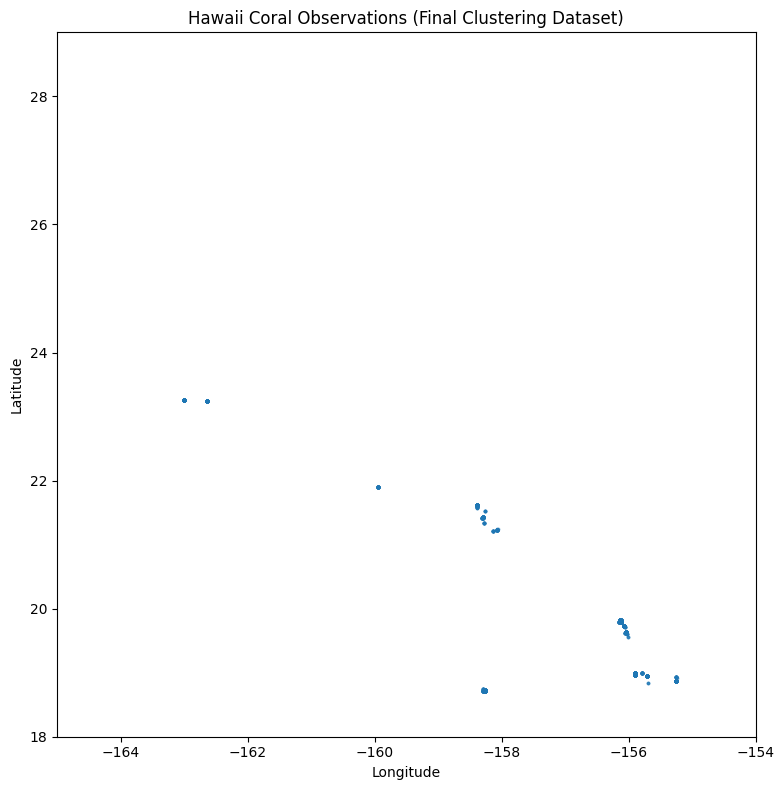

In [96]:
fig, ax = plt.subplots(figsize=(8, 8))

#plotting coral points
gdf_final.plot(
    ax=ax,
    markersize=3,
    alpha=0.6
)

#zoom window
ax.set_xlim(-165, -154)
ax.set_ylim(18, 29)

ax.set_title("Hawaii Coral Observations (Final Clustering Dataset)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()


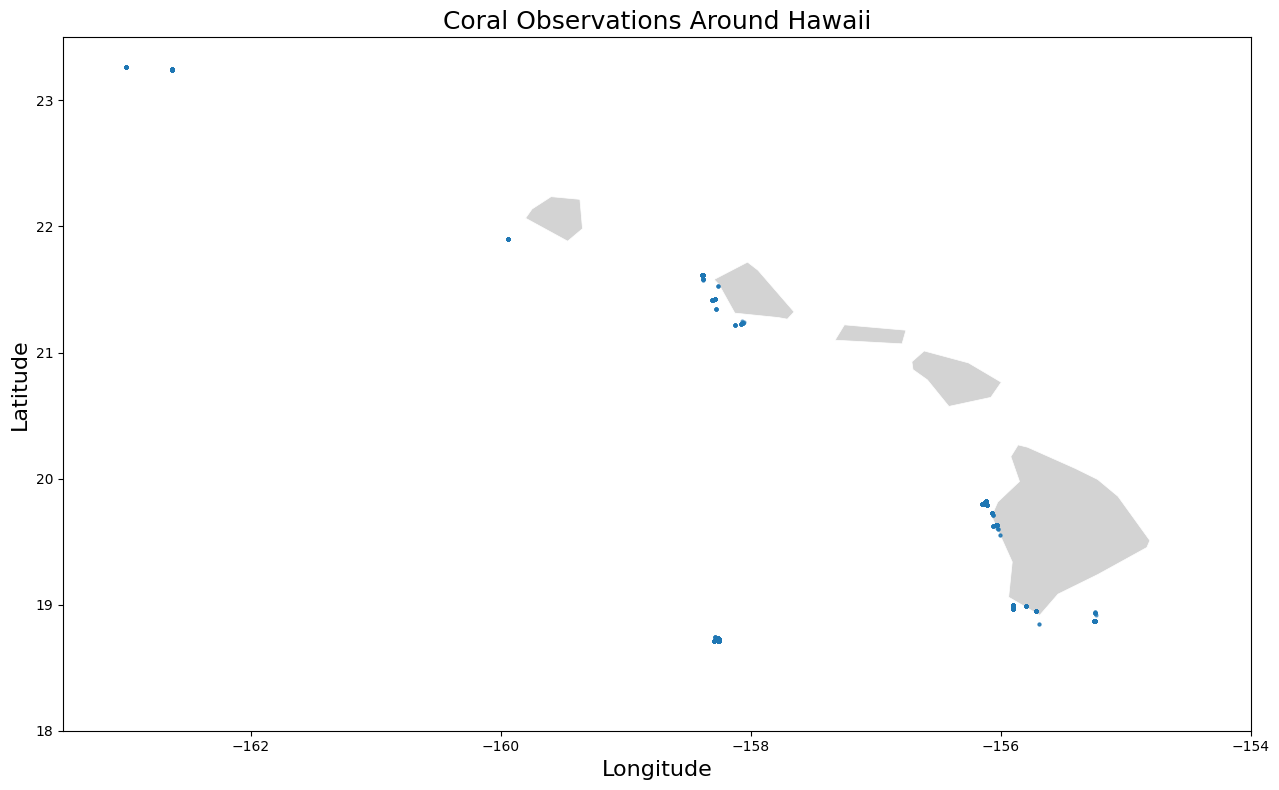

In [97]:
#build GeoDataFrame from final_df
gdf_final = gpd.GeoDataFrame(
    final_df.dropna(subset=["longitude", "latitude"]).copy(),
    geometry=gpd.points_from_xy(final_df.dropna(subset=["longitude", "latitude"])["longitude"],
                                final_df.dropna(subset=["longitude", "latitude"])["latitude"]),
    crs="EPSG:4326"
)

#load world map
world = gpd.read_file("ne_110m_admin_0_countries.shp")
if world.crs is None:
    world = world.set_crs("EPSG:4326")
world = world.to_crs(gdf_final.crs)

#compute bounds
minx, miny, maxx, maxy = gdf_final.total_bounds

#adding padding
xpad = (maxx - minx) * 0.1 if maxx > minx else 1
ypad = (maxy - miny) * 0.1 if maxy > miny else 1

#plot
fig, ax = plt.subplots(figsize=(14, 8))

world.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

gdf_final.plot(
    ax=ax,
    markersize=4,
    alpha=0.6
)

#hawaii extent (rough)
ax.set_xlim(-163.5, -154.0)
ax.set_ylim(18.0, 23.5)

ax.set_title("Coral Observations Around Hawaii", fontsize=18)
ax.set_xlabel("Longitude", fontsize = 16)
ax.set_ylabel("Latitude", fontsize = 16)

plt.tight_layout()
plt.show()


This looks good, our data still covers multiple islands in Hawaii

## Species Distribution

In [98]:
species_counts = (final_df["ScientificName"]
                  .value_counts()
                  .reset_index())

species_counts.columns = ["ScientificName", "count"]
species_counts.head(10)

,ScientificName,count
0,Kulamanamana haumeaae,343
1,Calibelemnon symmetricum,282
2,Isididae,246
3,Plexauridae,238
4,Corallium sp.,226
5,Primnoidae,153
6,Antipatharia,140
7,Enallopsammia rostrata,133
8,Corallium regale,131
9,Acanella sp.,103


We still have a solid distribution of counts of different corals

## Depth

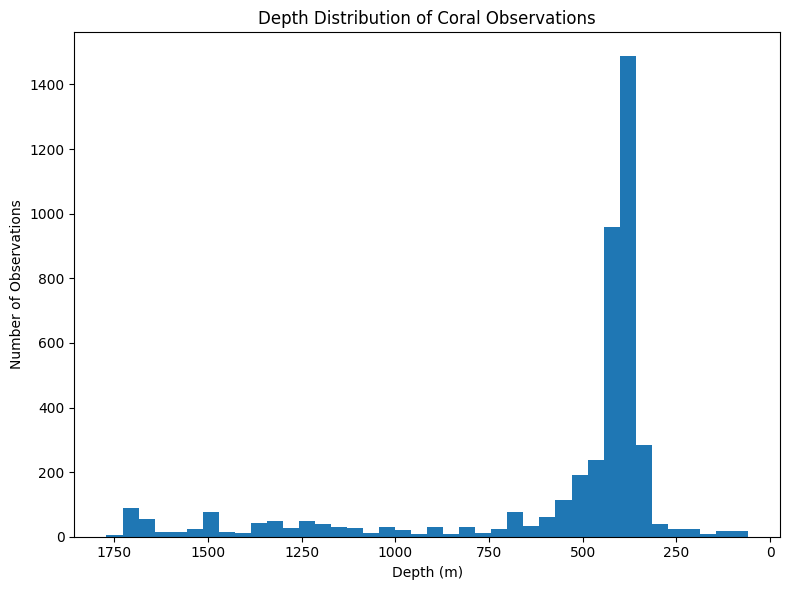

In [99]:
plt.figure(figsize=(8,6))

plt.hist(final_df["DepthInMeters"], bins=40)
plt.xlabel("Depth (m)")
plt.ylabel("Number of Observations")
plt.title("Depth Distribution of Coral Observations")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


We still span a wide range of depths

## Dates


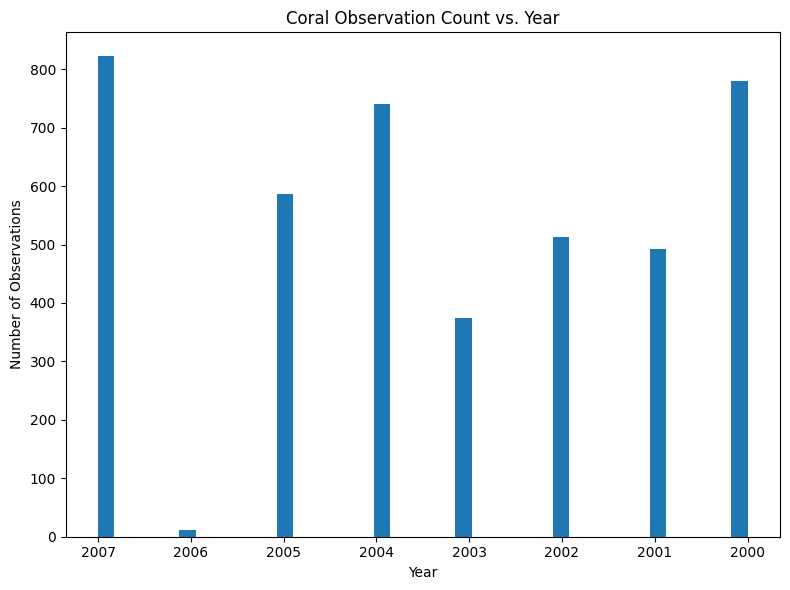

In [100]:
plt.figure(figsize=(8,6))

plt.hist(final_df["Year"], bins=40)
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.title("Coral Observation Count vs. Year")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


We still have a wide distribution of years, although our most recent data point is in 2007. Whereas the non-filtered df extended to 2016. Regardless, this anomoly detection model could still be applied to more modern data when available.

## Temp

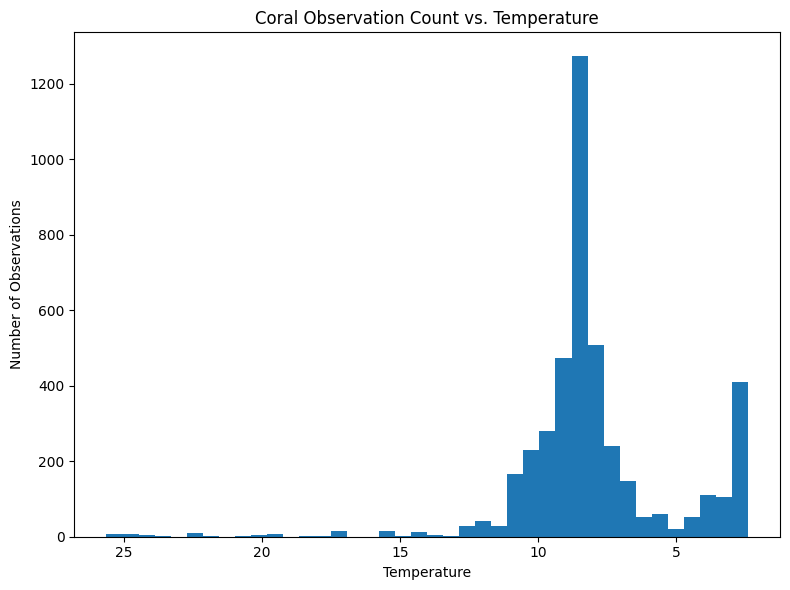

In [101]:
plt.figure(figsize=(8,6))

plt.hist(final_df["temp"], bins = 40)
plt.xlabel("Temperature")
plt.ylabel("Number of Observations")
plt.title("Coral Observation Count vs. Temperature")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

Nice range of temperatures, clearly aligns with depth.

## Salinity

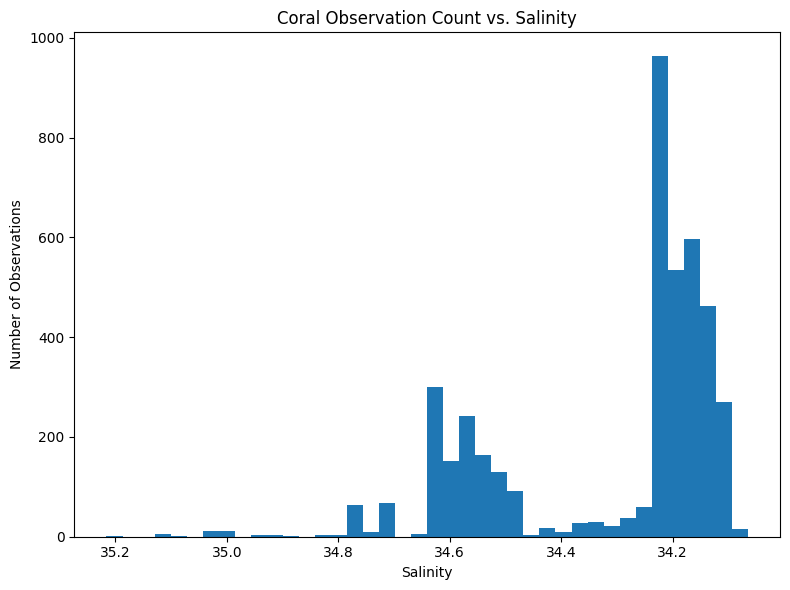

In [102]:
plt.figure(figsize=(8,6))

plt.hist(final_df["salin"], bins = 40)
plt.xlabel("Salinity")
plt.ylabel("Number of Observations")
plt.title("Coral Observation Count vs. Salinity")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

Interesting two peaks here

## Oxygen Saturation Percent

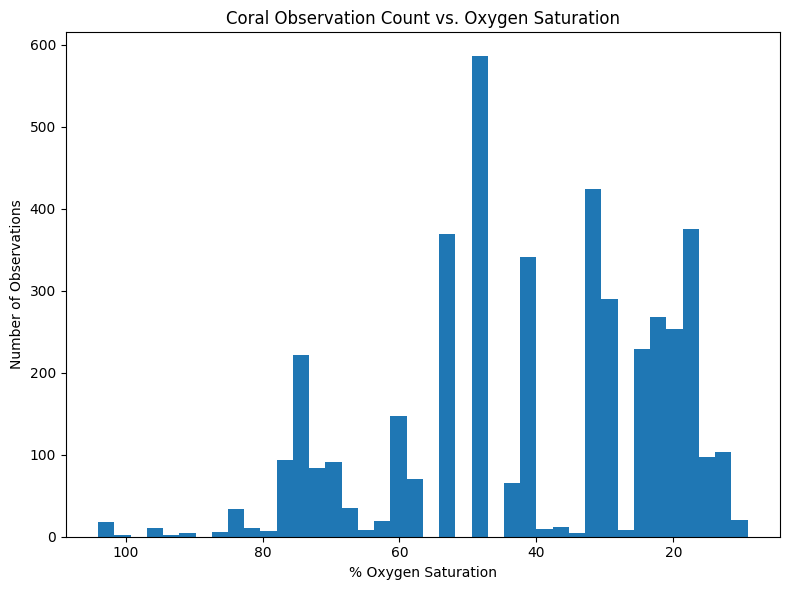

In [103]:
plt.figure(figsize=(8,6))

plt.hist(final_df["ox_sat"], bins = 40)
plt.xlabel("% Oxygen Saturation")
plt.ylabel("Number of Observations")
plt.title("Coral Observation Count vs. Oxygen Saturation")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

## Scatter Matrix

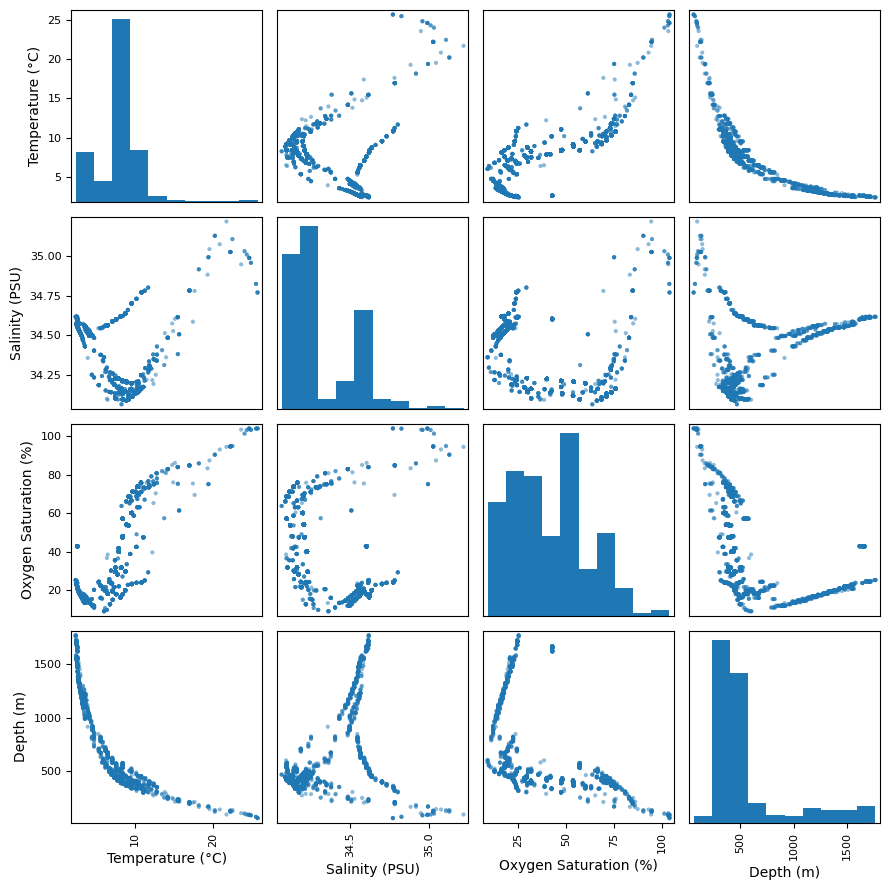

In [104]:
cols = ["temp","salin","ox_sat","DepthInMeters"]

rename_dict = {
    "temp": "Temperature (°C)",
    "salin": "Salinity (PSU)",
    "ox_sat": "Oxygen Saturation (%)",
    "DepthInMeters": "Depth (m)"
}

df_plot = final_df[cols].rename(columns=rename_dict)

pd.plotting.scatter_matrix(df_plot, figsize=(9,9), diagonal="hist")

plt.tight_layout()
plt.show()


## Last Transformations

We see that depth is skewed, so we take the log

In [105]:
final_df["log_depth"] = np.log10(final_df["DepthInMeters"])


In [106]:
final_df.head()

,ScientificName,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
0,Stichopathes sp.,18.94637,-155.71550,2002,165.0,19.245,34.881,83.342,2.217484
1,Stichopathes sp.,18.94637,-155.71550,2002,135.0,22.417,35.105,94.884,2.130334
2,Stichopathes sp.,24.57055,-167.31575,2003,211.0,16.923,34.781,84.844,2.324282
3,Stichopathes sp.,23.26355,-162.99783,2003,364.0,10.695,34.175,73.659,2.561101
4,Stichopathes sp.,23.26355,-162.99783,2003,406.0,10.077,34.133,71.149,2.608526


In [107]:
final_df.describe()

,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
count,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,17.758806,-160.030245,2003.325156,566.565610,7.954181,34.310337,40.444944,2.691968
std,8.166801,4.938811,2.424038,366.773002,2.890395,0.201018,19.526319,0.212021
min,-14.218710,-179.570980,2000.000000,59.000000,2.409000,34.065000,9.153000,1.770852
25%,18.728550,-160.024290,2001.000000,387.000000,7.474000,34.162000,23.285000,2.587711
50%,18.973500,-158.261700,2004.000000,409.000000,8.356000,34.212000,40.069000,2.611723
75%,21.616670,-156.134130,2005.000000,503.000000,8.910000,34.524000,54.099000,2.701568
max,28.969230,-155.240850,2007.000000,1771.000000,25.629000,35.216000,104.023000,3.248219


We also notice that the Hawaiian Observatory Extends to the South Pacific, so we exclude those coral as well.

In [108]:
final_df = final_df[
    (final_df["latitude"] >= 18) &
    (final_df["latitude"] <= 29) &
    (final_df["longitude"] >= -165) &
    (final_df["longitude"] <= -154)
].copy()

# Next Steps

For Clustering:


*   Do not use latitude/longitude, this will just rediscover islands
*   Cluster seperately by species




## Saving CSV for Later Processing

In [109]:
final_df.to_csv("/content/drive/Shareddrives/ML Final Project/Data/coral_df.csv")